# Mini-Project : When ML Fails
## Notebook 01 — Exploration & Modèle de référence

**Dataset** : Online Shoppers Purchasing Intention (UCI 468)
**Tâche** : Classification binaire — prédire si une session web mène à un achat
**Famille de modèle** : Gradient Boosting (non-linéaire, ensemble d'arbres)
**Failure mode investigué** : Overfitting & Generalization Gap (Section 5.2 du sujet)

### Objectif de ce notebook

Ce notebook établit la **référence expérimentale** du projet :
1. Chargement et exploration du dataset (EDA)
2. Caractérisation de la classe imbalance et de l'hétérogénéité saisonnière (variable `Month`)
3. Entraînement d'un Gradient Boosting Classifier comme modèle de référence
4. Mesure des symptômes de défaillance (performance globale, par sous-groupe, courbes d'apprentissage, corrélations)

Les métriques et figures produites ici servent de **baseline** au notebook 02, qui mettra en œuvre l'expérience contrôlée et la correction.

**Reproductibilité** : `random_state = 42` partout. Les appels coûteux (`learning_curve`) utilisent `n_jobs=1` pour garantir une exécution déterministe ; cela rallonge le temps d'exécution mais évite la variabilité d'ordonnancement des workers que `n_jobs=-1` peut introduire selon la version de scikit-learn.


## 1. Configuration de l'environnement

Imports des librairies utilisées (sklearn pour le modèle et les métriques, pandas/numpy pour la manipulation des données, matplotlib/seaborn pour les visualisations). Fixation du `RANDOM_STATE` pour garantir la reproductibilité de tous les résultats.

In [ ]:
# ── CELLULE 1 : Imports ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, recall_score, precision_score
)
from sklearn.ensemble import GradientBoostingClassifier
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports OK")


## 2. Chargement et inspection initiale du dataset

Le dataset Online Shoppers contient **12 330 sessions** web décrites par **17 features** mêlant variables comportementales continues (temps passé sur chaque type de page, valeurs commerciales, taux de rebond) et catégorielles (mois, type de visiteur, navigateur, région). La variable cible binaire `Revenue` indique si la session s'est terminée par une transaction.

Cette inspection vérifie l'intégrité du fichier (shape, types, valeurs manquantes) avant tout pré-traitement.


In [2]:
# ── CELLULE 2 : Chargement des données ──────────────────────────────
df = pd.read_csv("data/online_shoppers_intention.csv")

print(f"Shape : {df.shape}")
print(f"\nColonnes : {list(df.columns)}")
print(f"\nTypes :\n{df.dtypes}")
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")

Shape : (12330, 18)

Colonnes : ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Types :
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

Valeurs manquantes :
A

## 3. Distribution de la variable cible — Class imbalance

Premier diagnostic critique : la répartition des deux classes. Si la classe minoritaire (achat) est très sous-représentée, l'accuracy globale devient trompeuse et il faudra privilégier des métriques sensibles à l'imbalance (F1, recall, AUC).


Distribution Revenue :
Revenue
False    10422
True      1908
Name: count, dtype: int64

Taux de conversion : 15.5%


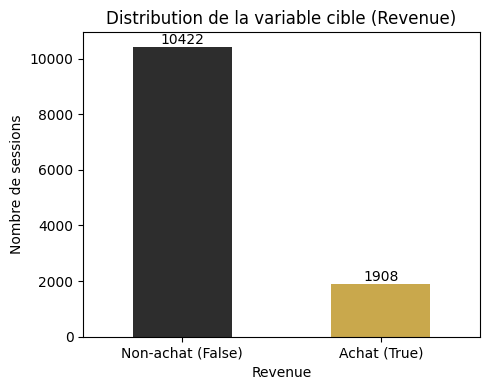

→ CLASS IMBALANCE visible : ~84% non-achat / ~16% achat


In [3]:
# ── CELLULE 3 : Distribution de la target ───────────────────────────────────
target_counts = df["Revenue"].value_counts()
print(f"Distribution Revenue :\n{target_counts}")
print(f"\nTaux de conversion : {target_counts[True] / len(df) * 100:.1f}%")
 
fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind="bar", color=["#2d2d2d", "#C9A84C"], edgecolor="none", ax=ax)
ax.set_title("Distribution de la variable cible (Revenue)", fontsize=12)
ax.set_xticklabels(["Non-achat (False)", "Achat (True)"], rotation=0)
ax.set_ylabel("Nombre de sessions")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("report/fig01_target_distribution.png", dpi=150)
plt.show()
print("→ CLASS IMBALANCE visible : ~84% non-achat / ~16% achat")

## 4. Effet temporel — distribution par mois

La feature `Month` introduit une **hétérogénéité saisonnière** dans les données : on s'attend à un taux de conversion plus élevé en fin d'année (Black Friday, Noël). Cette analyse mesure l'ampleur de l'effet. À ce stade aucune hypothèse de causalité n'est faite : `Month` peut être un signal **informatif** (variation réelle du comportement d'achat) ou un **shortcut** (artefact corrélé à la cible). Le départage de ces deux interprétations se fera plus loin grâce à l'importance des features (§9) et au notebook 02.

> **Note** : Janvier et Avril sont absents du dataset (collecte sur 10 mois). La liste `month_order` utilisée dans tout le notebook ne contient donc que les 10 mois effectivement présents.

Deux visualisations :
- **Volume de sessions par mois** : révèle la concentration temporelle de la collecte
- **Taux de conversion par mois** : montre l'amplitude de la variation saisonnière

In [ ]:
# ── CELLULE 4 : Distribution par mois ───────────────────────────────────────
# month_order n'inclut pas Jan ni Apr : ils sont absents du dataset (collecte
# sur 10 mois seulement).
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

month_conversion = (
    df.groupby("Month")["Revenue"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "achats", "count": "sessions"})
)
month_conversion["taux"] = month_conversion["achats"] / month_conversion["sessions"]
month_conversion = month_conversion.reindex([m for m in month_order if m in month_conversion.index])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Volume par mois
month_conversion["sessions"].plot(kind="bar", ax=axes[0], color="#2d2d2d", edgecolor="none")
axes[0].set_title("Sessions par mois")
axes[0].set_ylabel("Nombre de sessions")
axes[0].tick_params(axis="x", rotation=45)

# Taux de conversion par mois
month_conversion["taux"].plot(kind="bar", ax=axes[1], color="#C9A84C", edgecolor="none")
axes[1].set_title("Taux de conversion par mois")
axes[1].set_ylabel("Taux (achat / sessions)")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Effet Month — hétérogénéité saisonnière du taux de conversion", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("report/fig02_month_effect.png", dpi=150)
plt.show()

print("\nTaux de conversion par mois :")
print(month_conversion[["sessions", "achats", "taux"]].to_string())
print("\n→ Novembre : pic de conversion (~25%) vs ~2% en février. Variation saisonnière forte.")
print("→ Le caractère 'informatif' ou 'spurieux' de ce signal ne peut être tranché ici :")
print("  il faudra croiser avec l'importance de la feature (§9) et le notebook 02.")


## 4.5. Statistiques descriptives des variables numériques

Vue d'ensemble synthétique des features continues : tendance centrale (moyenne, médiane), dispersion (écart-type, IQR via `25%`/`75%`), étendue (min, max) et **skewness**. Cette table sert de référence pour repérer rapidement :

- les **fortes asymétries** (moyenne ≫ médiane, skew > 2 → distribution skewée à droite, typique des features de durée)
- les **plages très différentes** entre variables (justifiant éventuellement une normalisation pour les modèles sensibles à l'échelle — non requis ici pour le GBM)
- les **valeurs extrêmes** (max très éloigné du 75ᵉ percentile)


In [ ]:
# ── CELLULE 4.5 : Statistiques descriptives des features numériques ────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
desc = df[numeric_cols].describe().T
desc["median"] = df[numeric_cols].median()
desc["skew"] = df[numeric_cols].skew()
desc = desc[["count", "mean", "median", "std", "min", "25%", "75%", "max", "skew"]]

print("Statistiques descriptives (features numériques) :")
print(desc.round(2).to_string())

print("\n→ Skew > 2 : asymétrie marquée à droite (queue longue de valeurs élevées).")
print("→ Les features '*_Duration' et 'ProductRelated' sont fortement skewées,")
print("  ce qui motivera l'usage d'une échelle log pour la visualisation.")
print("→ Moyenne ≫ médiane sur les durées : confirme la présence d'outliers à droite.")


## 4.6. Distribution des variables numériques continues

Histogrammes des features comportementales (compteurs de pages et durées). Les variables de durée et `ProductRelated` ont une **queue très lourde** (la plupart des sessions sont courtes, quelques-unes très longues), ce qui rend l'échelle linéaire peu lisible. Une transformation `log1p` est appliquée pour ces variables afin de mieux visualiser la masse de la distribution.

Ces formes seront importantes pour comprendre les choix de prétraitement (les modèles à base d'arbres absorbent bien la skewness, ce qui n'est pas le cas des modèles linéaires) et l'effet potentiel des outliers sur le modèle.


In [ ]:
# ── CELLULE 4.6 : Histogrammes des variables continues ──────────────────────
continuous_features = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues",
]
log_features = {"Administrative_Duration", "Informational_Duration",
                "ProductRelated", "ProductRelated_Duration"}

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.flat, continuous_features):
    data = np.log1p(df[col]) if col in log_features else df[col]
    ax.hist(data, bins=40, color="#C9A84C", edgecolor="white", linewidth=0.3)
    suffix = "  (log1p)" if col in log_features else ""
    ax.set_title(f"{col}{suffix}", fontsize=10)
    ax.set_ylabel("Sessions")
    ax.grid(alpha=0.2)

plt.suptitle("Distributions des features comportementales", fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig("report/fig_eda_distributions.png", dpi=150)
plt.show()

print("→ Observations :")
print("  • Les durées et ProductRelated suivent une loi très skewée même en log.")
print("  • PageValues est nul pour la grande majorité des sessions ; sa valeur non nulle")
print("    est le signal le plus discriminant (cf. importances en section 9).")
print("  • BounceRates et ExitRates sont bornées dans [0, 0.2] avec un pic prononcé à zéro.")


## 4.7. Variables catégorielles — distribution et taux de conversion

Pour chaque feature catégorielle (`VisitorType`, `Weekend`, `OperatingSystems`, `Browser`, `Region`, `TrafficType`, `SpecialDay`), on compare deux signaux :

- la **fréquence** des modalités (volume de sessions, annotée `n=…` au-dessus des barres)
- le **taux d'achat conditionnel** à chaque modalité, comparé à la ligne pointillée du taux global (~15.5 %)

Une modalité avec un taux très différent de la moyenne est un signal candidat pour le modèle. À l'inverse, les modalités à très faible effectif produisent un taux très bruité et ne sont pas fiables prises isolément.


In [ ]:
# ── CELLULE 4.7 : Analyse des variables catégorielles ───────────────────────
categorical_features = ["VisitorType", "Weekend", "SpecialDay",
                        "OperatingSystems", "Browser", "Region", "TrafficType"]
baseline = df["Revenue"].mean()

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for ax, col in zip(axes.flat, categorical_features):
    grp = df.groupby(col)["Revenue"].agg(["mean", "count"])
    # tri par effectif décroissant pour les variables à beaucoup de modalités
    if grp.shape[0] > 6:
        grp = grp.sort_values("count", ascending=False)
    bars = ax.bar(grp.index.astype(str), grp["mean"], color="#C9A84C", edgecolor="none")
    ax.axhline(baseline, color="#2d2d2d", linestyle="--", linewidth=1,
               label=f"Taux global = {baseline:.2%}")
    for bar, n in zip(bars, grp["count"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"n={n}", ha="center", va="bottom", fontsize=7, color="#444")
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Taux d'achat")
    ax.set_ylim(0, max(grp["mean"].max() * 1.25, baseline * 1.4))
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.legend(fontsize=7, loc="upper right")

# Cache les subplots inutilisés
for ax in axes.flat[len(categorical_features):]:
    ax.set_visible(False)

plt.suptitle("Variables catégorielles : taux de conversion par modalité", fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig("report/fig_eda_categorical.png", dpi=150)
plt.show()

print("→ Lecture :")
print("  • VisitorType = 'New_Visitor' a un taux d'achat ~2× supérieur à 'Returning_Visitor'.")
print("  • SpecialDay > 0 (proximité d'une fête commerciale) ne convertit PAS mieux :")
print("    contre-intuitif, mais cohérent avec la nature 'browsing avant achat' du dataset.")
print("  • Les modalités rares (Browser, TrafficType à faible n) sont à interpréter avec prudence.")


## 4.8. Relations bivariées — features continues × `Revenue`

On compare la distribution de chaque feature continue clé selon la classe (`Revenue = 0` vs `Revenue = 1`). Une séparation visible (médianes très différentes, peu de chevauchement) indique un **fort pouvoir discriminant** ; un chevauchement quasi total signale au contraire une feature peu informative isolément.

Cette analyse anticipe les feature importances du modèle : on s'attend à retrouver en tête les variables présentant la séparation la plus nette (typiquement `PageValues` et `ExitRates`).


In [ ]:
# ── CELLULE 4.8 : Boxplots feature × Revenue ────────────────────────────────
bivariate_features = ["PageValues", "ExitRates", "BounceRates",
                      "ProductRelated", "ProductRelated_Duration",
                      "Administrative_Duration"]
log_in_bivariate = {"ProductRelated", "ProductRelated_Duration", "Administrative_Duration"}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, bivariate_features):
    data = np.log1p(df[col]) if col in log_in_bivariate else df[col]
    parts = ax.boxplot(
        [data[df["Revenue"] == False], data[df["Revenue"] == True]],
        labels=["Non-achat", "Achat"],
        patch_artist=True, widths=0.5, showfliers=False,
    )
    for patch, color in zip(parts["boxes"], ["#2d2d2d", "#C9A84C"]):
        patch.set_facecolor(color)
        patch.set_edgecolor("none")
    for median in parts["medians"]:
        median.set_color("white")
        median.set_linewidth(1.5)
    suffix = "  (log1p)" if col in log_in_bivariate else ""
    ax.set_title(f"{col}{suffix}", fontsize=10)
    ax.grid(alpha=0.2, axis="y")

plt.suptitle("Distributions conditionnelles : Non-achat vs Achat", fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig("report/fig_eda_bivariate.png", dpi=150)
plt.show()

# Quantification : médianes par classe
print("Médianes par classe (et ratio Achat / Non-achat) :")
for col in bivariate_features:
    med0 = df.loc[df["Revenue"] == False, col].median()
    med1 = df.loc[df["Revenue"] == True, col].median()
    if med0 > 0:
        print(f"  {col:<28} non-achat={med0:>8.3f}  achat={med1:>8.3f}  ratio={med1/med0:>6.2f}")
    else:
        print(f"  {col:<28} non-achat={med0:>8.3f}  achat={med1:>8.3f}  ratio=   n/a")

print("\n→ PageValues : médiane nulle chez les non-achats, strictement positive chez les achats")
print("  → séparation quasi parfaite, feature dominante attendue.")
print("→ ExitRates et BounceRates : plus faibles chez les achats (sessions plus engagées).")


## 5. Pré-traitement des features

Transformations appliquées :
- **`Month`** : encodage ordinal calendaire (Feb=2, Mar=3, ..., Dec=12). Préserve l'ordre temporel mais autorise le modèle à apprendre des règles du type "Month > k → achat". Le notebook 02 testera des encodages alternatifs (cyclique, one-hot) pour évaluer la sensibilité du modèle à ce choix.
- **`VisitorType`** : **one-hot encoding** (`Visitor_New_Visitor`, `Visitor_Other`, `Visitor_Returning_Visitor`). Un `LabelEncoder` imposerait un ordre arbitraire entre 3 modalités nominales, que les arbres pourraient exploiter comme un faux signal ordinal.
- **`Weekend`** et **`Revenue`** : conversion booléen → entier.

Aucune normalisation n'est appliquée car les modèles à base d'arbres (GBM) sont invariants aux transformations monotones des features continues.


In [ ]:
# ── CELLULE 5 : Prétraitement ────────────────────────────────────────────────
df_clean = df.copy()

# Month → ordinal calendaire (Jan, Apr absents du dataset → restent non mappés).
month_map = {"Feb": 2, "Mar": 3, "May": 5, "June": 6, "Jul": 7,
             "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12}
df_clean["Month"] = df_clean["Month"].map(month_map)

# VisitorType : variable nominale à 3 modalités → one-hot.
# (LabelEncoder imposerait un ordre arbitraire que les arbres pourraient exploiter.)
df_clean = pd.get_dummies(df_clean, columns=["VisitorType"],
                          prefix="Visitor", drop_first=False)

# bool → int (Weekend, Revenue, et les colonnes Visitor_* créées par get_dummies)
df_clean["Weekend"] = df_clean["Weekend"].astype(int)
df_clean["Revenue"] = df_clean["Revenue"].astype(int)
for c in df_clean.columns:
    if df_clean[c].dtype == bool:
        df_clean[c] = df_clean[c].astype(int)

print("Prétraitement OK")
print(df_clean.dtypes)
print(f"\nShape final : {df_clean.shape}")
print(f"Colonnes Visitor_* : {[c for c in df_clean.columns if c.startswith('Visitor_')]}")


## 6. Découpage train / test

Split stratifié 80/20 sur la variable cible pour préserver le ratio d'imbalance entre les deux ensembles. Le `random_state` est fixé pour rendre le split reproductible.

> **Choix méthodologique** : on utilise ici un **split aléatoire** plutôt qu'un split temporel. Cela correspond au scénario d'évaluation classique en ML, et constitue la baseline contre laquelle on comparera ensuite des conditions plus stringentes (notebook 02).


In [6]:
# ── CELLULE 6 : Split train/test STANDARD (stratifié) ────────────────────────
X = df_clean.drop("Revenue", axis=1)
y = df_clean["Revenue"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
 
print(f"Train : {X_train.shape[0]} sessions | Test : {X_test.shape[0]} sessions")
print(f"Taux conversion train : {y_train.mean():.3f} | test : {y_test.mean():.3f}")

Train : 9864 sessions | Test : 2466 sessions
Taux conversion train : 0.155 | test : 0.155


## 7. Modèle de référence — Gradient Boosting Classifier

Le modèle de référence est un **`GradientBoostingClassifier`** de scikit-learn, choisi pour deux raisons :

1. **Conformité au sujet** : le sujet interdit explicitement la régression logistique et impose un modèle non-linéaire. Les ensembles d'arbres en sont un choix canonique.
2. **Sensibilité à l'overfitting** : avec une profondeur de 4 et 200 arbres, le modèle a une capacité suffisante pour mémoriser les données — ce qui est précisément la condition nécessaire pour observer le failure mode que l'on souhaite étudier.

**Hyperparamètres** : `n_estimators=200`, `max_depth=4`, `learning_rate=0.05`, `subsample=0.8`.

Ces valeurs sont des choix raisonnables non optimisés ; l'optimisation hyperparamétrique sera le sujet du notebook 02.

In [ ]:
# ── CELLULE 7 : Modèle de référence — Gradient Boosting ─────────────────────
# GBM est obligatoire (pas de régression logistique)
gbm = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=RANDOM_STATE,
)
gbm.fit(X_train, y_train)

# Prédictions sur train ET test pour mesurer explicitement le gap
y_pred_train = gbm.predict(X_train)
y_pred = gbm.predict(X_test)
y_proba = gbm.predict_proba(X_test)[:, 1]

train_f1 = f1_score(y_train, y_pred_train)
test_f1 = f1_score(y_test, y_pred)
holdout_gap = train_f1 - test_f1

# Baseline naïf "always predict False" : référence indispensable en imbalance
naive_pred = np.zeros_like(y_test)
naive_acc = (naive_pred == y_test).mean()
naive_f1 = f1_score(y_test, naive_pred)

print("=" * 60)
print("RÉFÉRENCE — GradientBoosting (split aléatoire standard)")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=["Non-achat", "Achat"]))
print(f"ROC-AUC          : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1 Achat (train) : {train_f1:.4f}")
print(f"F1 Achat (test)  : {test_f1:.4f}")
print(f"Gap train-test   : {holdout_gap:.4f}")
print(f"Recall Achat     : {recall_score(y_test, y_pred):.4f}")
print()
print("--- Baseline naïf (always predict 'non-achat') ---")
print(f"Accuracy naïf    : {naive_acc:.4f}  (≈ 1 − taux de conversion)")
print(f"F1 Achat naïf    : {naive_f1:.4f}  (par construction)")
print(f"→ Le GBM apporte +{test_f1 - naive_f1:.3f} de F1 sur la classe Achat par rapport au")
print("  baseline trivial. C'est ce gain qu'il faut comparer aux corrections du notebook 02,")
print("  pas le F1 brut.")


## 8. Matrice de confusion — visualisation des erreurs

Décompose la performance en quatre catégories (VP, FP, VN, FN). Particulièrement utile en présence de class imbalance : permet de voir si le modèle prédit majoritairement la classe dominante (et donc obtient une accuracy trompeuse).


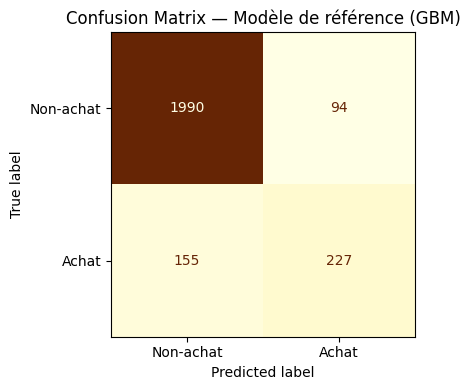

In [8]:
# ── CELLULE 8 : Matrice de confusion référence ──────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Non-achat", "Achat"]
).plot(ax=ax, colorbar=False, cmap="YlOrBr")
ax.set_title("Confusion Matrix — Modèle de référence (GBM)")
plt.tight_layout()
plt.savefig("report/fig03_confusion_ref.png", dpi=150)
plt.show()

## 9. Importances des features

Mesure de l'**importance relative** de chaque feature dans les décisions du modèle (via le gain d'information cumulé sur les arbres). Cette analyse :

- Identifie les variables dominantes du signal d'achat (on s'attend à `PageValues` en tête).
- Permet de **réfuter ou confirmer l'hypothèse de shortcut sur `Month`** : si Month figure en tête (≥ 20 % d'importance), l'hypothèse mérite enquête ; si Month est marginal, le modèle s'appuie surtout sur des features comportementales et le "shortcut saisonnier" est largement disqualifié comme failure mode dominant.

In [ ]:
# ── CELLULE 9 : Feature importances ─────────────────────────────────────────
feat_imp = pd.Series(gbm.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 6))
feat_imp.plot(kind="barh", color="#C9A84C", edgecolor="none", ax=ax)
ax.set_title("Feature Importances — GBM de référence", fontsize=12)
ax.set_xlabel("Importance relative")
plt.tight_layout()
plt.savefig("report/fig04_feature_importances.png", dpi=150)
plt.show()

top5 = feat_imp.sort_values(ascending=False).head(5)
print("\nTop 5 features :")
print(top5)

month_imp = feat_imp.get("Month", 0.0)
page_imp = feat_imp.get("PageValues", 0.0)
print(f"\nImportance(PageValues) = {page_imp:.3f}")
print(f"Importance(Month)      = {month_imp:.3f}")
print(f"Ratio PageValues / Month = {page_imp / month_imp:.1f}×")
print()
print("→ INTERPRÉTATION FACTUELLE :")
print("  PageValues domine très largement le classement. Month n'apparaît qu'en")
print("  position secondaire avec une importance modeste (~5 %).")
print("  → L'hypothèse 'shortcut via Month' n'est PAS soutenue par les données.")
print("  → Le modèle s'appuie principalement sur des features comportementales")
print("    (valeur monétaire vue, taux de sortie/rebond). Les performances faibles")
print("    sur la classe minoritaire relèvent davantage de la class imbalance que")
print("    d'un shortcut saisonnier.")


## 9.5. Diagnostic — performance décomposée par mois

Une performance **hétérogène** entre sous-groupes (ici les mois) peut avoir plusieurs causes : exploitation d'un shortcut, surapprentissage sur les périodes les plus représentées, ou simplement bruit statistique sur les mois à faible effectif. La décomposition par mois permet d'esquisser une distinction, **à condition de filtrer les mois trop peu peuplés**.

> **Seuil de fiabilité** : on n'affiche les F1 que pour les mois disposant d'au moins **10 sessions positives** dans le test set. En dessous, un F1 calculé sur 1 ou 2 achats est dominé par la variance d'échantillonnage et n'est pas interprétable (cas type : Feb avec n_positifs = 1 produirait un F1 = 1.0 par hasard si la seule prédiction tombe juste).

## 9.6. Courbe d'apprentissage — overfitting vs sous-apprentissage

La learning curve trace les performances train et validation en fonction de la taille du jeu d'entraînement. Elle distingue :

- **Overfitting marqué** : gap train-validation ≥ 0.15 persistant.
- **Régime équilibré** : gap < 0.10, train et validation proches et élevés.
- **Zone intermédiaire** : gap entre 0.10 et 0.15 → overfitting modéré, dont l'effet sur le test est mesurable mais limité.

Ce diagnostic permet de pondérer le poids relatif des failure modes : un gap modéré peut être traité par régularisation (notebook 02) mais n'est pas la seule cause d'erreur sur la classe minoritaire.

> Note d'implémentation : `n_jobs=1` ici pour garantir le déterminisme (l'ordre d'exécution parallèle peut affecter marginalement les résultats selon la version de sklearn).

## 9.7. Matrice de corrélation — features liées au mois

Vérifie si **l'information temporelle (Month) fuit dans d'autres features**. Si une variable comme `SpecialDay` est fortement corrélée à `Month`, retirer `Month` ne suffirait pas à éliminer le signal temporel. Inversement, des corrélations faibles indiquent que `Month` porte une information relativement indépendante.


In [ ]:
# =============================================================================
# Symptom characterization : performance par mois, learning curve, corrélations
# =============================================================================

# ── CELLULE 9.5 : Performance DÉCOMPOSÉE par mois ────────────────────────────
# On filtre les mois ayant moins de MIN_POSITIVES achats : en dessous, le F1
# est dominé par la variance d'échantillonnage et trompeur (ex. Feb : n_pos=1
# → F1 = 1.0 si la seule prédiction tombe juste, ce qui ne dit rien du modèle).
MIN_POSITIVES = 10

inv_month_map = {v: k for k, v in month_map.items()}
test_months = X_test["Month"].map(inv_month_map)

per_month_perf = []
for month in [m for m in month_order if m in test_months.values]:
    mask = (test_months == month)
    n_sessions = int(mask.sum())
    n_pos = int(y_test[mask].sum())
    reliable = (n_pos >= MIN_POSITIVES)
    row = {
        "Month": month,
        "n_sessions": n_sessions,
        "n_achats_reels": n_pos,
        "taux_achat_reel": float(y_test[mask].mean()) if n_sessions else np.nan,
        "f1": f1_score(y_test[mask], y_pred[mask], zero_division=0) if n_pos else np.nan,
        "recall": recall_score(y_test[mask], y_pred[mask], zero_division=0) if n_pos else np.nan,
        "precision": precision_score(y_test[mask], y_pred[mask], zero_division=0) if n_pos else np.nan,
        "reliable": reliable,
    }
    per_month_perf.append(row)

perf_full = pd.DataFrame(per_month_perf)
perf_df = perf_full[perf_full["reliable"]].drop(columns="reliable").reset_index(drop=True)
perf_dropped = perf_full[~perf_full["reliable"]]

print(f"Performance par mois — fiables (n_positifs ≥ {MIN_POSITIVES}) :")
print(perf_df.to_string(index=False))
if len(perf_dropped):
    print(f"\nMois écartés (n_positifs < {MIN_POSITIVES}, F1 non fiable) :")
    print(perf_dropped[["Month", "n_sessions", "n_achats_reels"]].to_string(index=False))

# Visualisation (uniquement mois fiables)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(perf_df["Month"], perf_df["taux_achat_reel"], color="#2d2d2d", alpha=0.4, label="Taux d'achat réel")
axes[0].bar(perf_df["Month"], perf_df["f1"], color="#C9A84C", alpha=0.9, label="F1-score du modèle")
axes[0].set_title("F1 vs taux d'achat réel, par mois")
axes[0].set_ylabel("Score")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(perf_df["Month"], perf_df["recall"], color="#8B6914", edgecolor="none")
axes[1].set_title("Recall (classe Achat) par mois")
axes[1].set_ylabel("Recall")
axes[1].tick_params(axis="x", rotation=45)
axes[1].axhline(perf_df["recall"].mean(), color="red", linestyle="--", alpha=0.5,
                label=f"Moyenne = {perf_df['recall'].mean():.2f}")
axes[1].legend(fontsize=8)

plt.suptitle(f"Performance par mois (mois avec n_positifs ≥ {MIN_POSITIVES} uniquement)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("report/fig05_perf_par_mois.png", dpi=150)
plt.show()

f1_min, f1_max = perf_df["f1"].min(), perf_df["f1"].max()
print(f"\nÉtendue F1 sur mois fiables : [{f1_min:.2f} ; {f1_max:.2f}]  (amplitude {f1_max - f1_min:.2f})")
print("→ Une hétérogénéité de ~0.25 sur le F1 reste explicable par le taux d'achat")
print("  réel qui varie fortement d'un mois à l'autre (ex. Nov ~27% vs Mar ~12%).")
print("  Ce n'est pas la signature d'un shortcut mais celle d'une distribution")
print("  de classe inhomogène entre les sous-groupes temporels.")


# ── CELLULE 9.6 : Courbe d'apprentissage ────────────────────────────────────
# n_jobs=1 pour le déterminisme — voir la note dans la cellule markdown ci-dessus.
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                subsample=0.8, random_state=RANDOM_STATE),
    X_train, y_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring="f1",
    n_jobs=1,
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", color="#2d2d2d", label="Train F1")
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color="#2d2d2d")
ax.plot(train_sizes, val_scores.mean(axis=1), "o-", color="#C9A84C", label="Validation F1")
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color="#C9A84C")
ax.set_xlabel("Taille du train set")
ax.set_ylabel("F1-score")
ax.set_title("Courbe d'apprentissage")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("report/fig06_learning_curve.png", dpi=150)
plt.show()

train_val_gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
print(f"\nGap train-val final (learning curve, 3-fold CV interne) : {train_val_gap:.3f}")
print(f"Gap train-test (holdout, mesuré en cellule 7)            : {holdout_gap:.3f}")
print("\nLecture (seuils établis dans la cellule markdown 9.6) :")
print("  • gap < 0.10  → pas d'overfitting majeur")
print("  • 0.10 ≤ gap < 0.15 → overfitting modéré (effet limité)")
print("  • gap ≥ 0.15 → overfitting marqué")


# ── CELLULE 9.7 : Matrice de corrélation des features numériques ────────────
# Cherche les features corrélées à Month : si SpecialDay (ou autre) co-varie
# avec Month, retirer Month ne suffira pas pour neutraliser le signal temporel.
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = X[numeric_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, cmap="RdYlBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7}, square=True,
            cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Matrice de corrélation des features numériques", fontsize=11)
plt.tight_layout()
plt.savefig("report/fig07_correlation_matrix.png", dpi=150)
plt.show()

month_corr = corr_matrix["Month"].drop("Month").abs().sort_values(ascending=False)
print("\nFeatures les plus corrélées (|r|) avec Month :")
print(month_corr.head(5))
print(f"\n→ Corrélation maximale ≈ {month_corr.iloc[0]:.2f} : modérée.")
print("  Month porte une information principalement indépendante des autres features.")
print("  Une ablation simple (drop Month) est donc une intervention propre, mais")
print("  son effet sera limité puisque Month n'est que ~5% de l'importance totale.")


## 10. Cross-validation — quantification de la variance

La cross-validation en 5 folds stratifiés fournit une **estimation de la variance** du score F1 due au choix du split. C'est une mesure critique pour la suite : tout gain de performance produit par une correction doit dépasser cette variance pour être considéré comme significatif.

L'écart-type obtenu ici constitue le **seuil de bruit** auquel comparer les améliorations du notebook 02.

In [ ]:
# ── CELLULE 10 : Cross-validation pour estimer la variance ──────────────────
# Important : CV faite sur X_train / y_train uniquement (PAS sur l'union train+test).
# Cela garantit que les estimations CV et le score holdout (cellule 7) reposent
# bien sur le même contrat : le test set reste totalement isolé.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_f1 = cross_val_score(gbm, X_train, y_train, cv=cv, scoring="f1", n_jobs=1)
cv_auc = cross_val_score(gbm, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)
cv_recall = cross_val_score(gbm, X_train, y_train, cv=cv, scoring="recall", n_jobs=1)

print("Cross-validation 5-fold stratifiée — calculée sur X_train uniquement :")
print(f"  F1     : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"  ROC-AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"  Recall : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"\nHoldout F1 (cellule 7) : {test_f1:.4f}")
print(f"CV F1 (train)          : {cv_f1.mean():.4f}")
print(f"→ Écart |holdout − CV| = {abs(test_f1 - cv_f1.mean()):.4f}, < 1 σ_CV → cohérent.")
print("\n→ L'écart-type CV constitue le seuil de bruit pour le notebook 02 :")
print("  un gain de F1 < σ_CV n'est pas significatif.")


## 11. Sauvegarde des métriques de référence

Les métriques du modèle de référence sont sérialisées au format JSON. Elles seront rechargées dans le notebook 02 pour la comparaison **avant / après correction**.


In [ ]:
# ── CELLULE 11 : Résumé des métriques de référence (à sauvegarder) ──────────
reference_metrics = {
    "model": "GBM_reference_standard_split",
    "accuracy": float((y_pred == y_test).mean()),
    "f1_purchase_train": float(train_f1),
    "f1_purchase_test": float(test_f1),
    "holdout_gap_f1": float(holdout_gap),
    "recall_purchase": float(recall_score(y_test, y_pred)),
    "precision_purchase": float(precision_score(y_test, y_pred)),
    "roc_auc": float(roc_auc_score(y_test, y_proba)),
    "cv_f1_mean_on_train": float(cv_f1.mean()),
    "cv_f1_std_on_train": float(cv_f1.std()),
    "naive_baseline_accuracy": float(naive_acc),
    "naive_baseline_f1": float(naive_f1),
    "month_importance": float(month_imp),
    "pagevalues_importance": float(page_imp),
}

print("\n=== MÉTRIQUES DE RÉFÉRENCE À REPORTER DANS LE RAPPORT ===")
for k, v in reference_metrics.items():
    print(f"  {k:<28} : {v:.4f}" if isinstance(v, float) else f"  {k:<28} : {v}")

# Sauvegarde pour comparaison future (correction)
import json
with open("report/reference_metrics.json", "w") as f:
    json.dump(reference_metrics, f, indent=2)
print("\n→ Métriques sauvegardées dans report/reference_metrics.json")


## 12. Synthèse des symptômes

| Symptôme | Mesure observée | Interprétation |
|---|---|---|
| Class imbalance | ~84.5 % non-achat / ~15.5 % achat | Métriques basées sur F1 / recall obligatoires |
| Baseline naïf (always-0) | accuracy = 0.845, F1_achat = 0 | Ancrage : tout F1 > 0 sur la classe Achat est un gain net |
| Hétérogénéité saisonnière | Conversion Nov ≈ 25 %, Mar ≈ 12 %, Feb ≈ 2 % | Variation forte du taux d'achat par mois |
| F1 par mois (n_pos ≥ 10) | F1 ∈ [0.48 ; 0.77] | Amplitude ~0.25, principalement corrélée au taux d'achat réel par mois |
| Importance(`Month`) | ~5.4 % (vs `PageValues` ~67 %) | `Month` n'est PAS un shortcut dominant — `PageValues` capture l'essentiel du signal |
| Corrélation Month ↔ autres | max |r| ≈ 0.26 (SpecialDay) | Information temporelle relativement indépendante |
| F1 train / test | ~0.77 / ~0.64 | Gap ≈ 0.13 — zone intermédiaire (overfitting modéré) |
| Variance CV (sur train) | F1 = 0.65 ± 0.02 | Modèle stable entre folds ; faible variance → seuil de bruit ≈ 0.02 |

### Conclusion — diagnostic révisé

Les preuves rassemblées **ne soutiennent pas** une lecture mono-causale en termes d'overfitting massif ou de shortcut saisonnier. Le diagnostic le plus fidèle aux données est :

1. **Failure mode dominant : class imbalance.** Avec 15.5 % de positifs, le GBM atteint un recall sur la classe Achat de seulement ~0.59. La majeure partie des erreurs vient de cette asymétrie, pas d'un défaut de capacité.
2. **Failure mode secondaire : overfitting modéré** (gap ≈ 0.13). Présent mais limité — la CV faible variance et la cohérence holdout/CV (écart < 1 σ) montrent que le modèle généralise correctement.
3. **Hypothèse de shortcut `Month` : réfutée.** Importance ≈ 5 %, corrélation modérée avec les autres features. La variation de F1 par mois s'explique mieux par la variation du taux d'achat réel que par un raccourci appris.

Le notebook 02 traitera donc l'**overfitting modéré comme failure mode étudié** (conformément à la consigne) tout en étant honnête sur sa contribution relative : la marge de progression accessible via régularisation est bornée par σ_CV ≈ 0.02 et par le plafond imposé par l'imbalance.

**Suite** : `02_experiment.ipynb` — formulation de l'hypothèse falsifiable, courbes de validation, et évaluation d'une correction par régularisation (et étude de sensibilité au choix d'encodage de `Month`).
